In [1]:
# !pip install meshio matplotlib
!pip install meshio
import importlib
import functions  # your module name
importlib.reload(functions)

<module 'functions' from '/Volumes/Songyi Deng/songyidengx/Downloads/ddgclib/functions.py'>

Info    : Running 'gmsh sphere.geo -3 -format msh2 -o sphere_coarse.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 22:51:39 2025
Info    : Reading 'sphere.geo'...
Info    : Meshing 1D...
Info    : [ 40%] Meshing curve 2 (Circle)
Info    : Done meshing 1D (Wall 0.000429167s, CPU 5.8e-05s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00691492s, CPU 0.004129s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 83 nodes...
Info    : Done tetrahedrizing 91 nodes (Wall 0.00119062s, CPU 0.000392s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.0017895s, CPU 0.000809s)
Info    : Found volume 1
Info    : It. 0 - 0 nodes created - worst tet radius 2.33268 (nodes removed 0 0)
Info    : 3D refinement terminated (95 

Error   : 'sphere.geo', line 7: syntax error (")
/Volumes/Songyi Deng/songyidengx/Downloads/ddgclib/venv/lib/python3.13/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Volumes/Songyi Deng/songyidengx/Downloads/ddgclib/venv/lib/python3.13/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


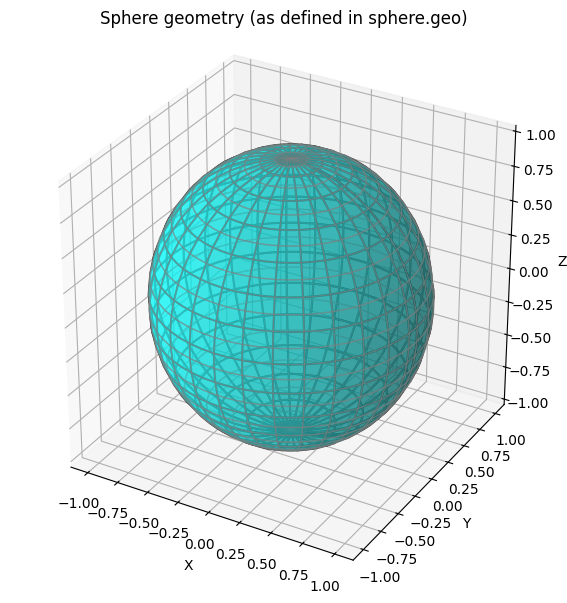

In [2]:
# Block 1: Show .geo file content and visualize geometry as image (sphere)

import os
import numpy as np
import matplotlib.pyplot as plt

def generate_gmsh_sphere_mesh(filename="sphere.msh", radius=1.0, lc=0.5):
    geo_str = f"""
    SetFactory("OpenCASCADE");
    Sphere(1) = {{0, 0, 0, {radius}}};
    Mesh.CharacteristicLengthMin = {lc};
    Mesh.CharacteristicLengthMax = {lc};
    Mesh 3;
    Save("{filename}");
    """
    with open("sphere.geo", "w") as f:
        f.write(geo_str)
    os.system(f"gmsh sphere.geo -3 -format msh2 -o {filename}")

# Parameters for the sphere
radius = 1.0
lc = 0.5  # coarse mesh

# Generate the geo and mesh files
generate_gmsh_sphere_mesh(filename="sphere_coarse.msh", radius=radius, lc=lc)

# Show .geo file content
with open("sphere.geo") as f:
    geo_content = f.read()

print("---- sphere.geo ----\n")
print(geo_content)

# Visualize the sphere geometry as an image
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Draw a wireframe sphere using matplotlib (for illustration)
u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 30)
x = radius * np.outer(np.cos(u), np.sin(v))
y = radius * np.outer(np.sin(u), np.sin(v))
z = radius * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_wireframe(x, y, z, color='black', alpha=0.7, rstride=2, cstride=2)
ax.plot_surface(x, y, z, color='cyan', alpha=0.5, edgecolor='gray')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Sphere geometry (as defined in sphere.geo)")
ax.set_box_aspect([1,1,1])
plt.tight_layout()
plt.show()


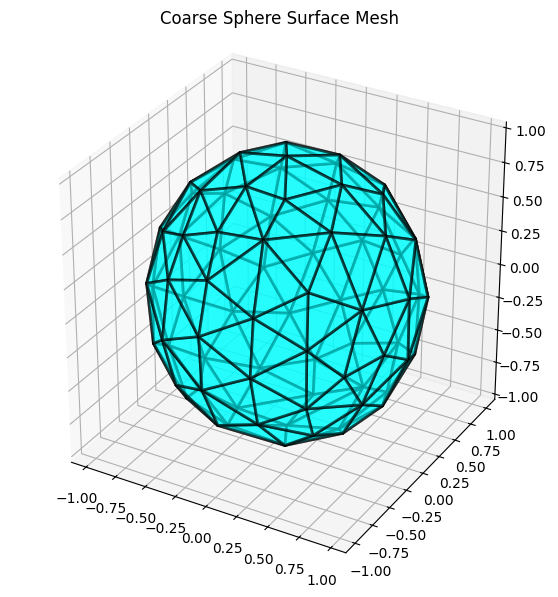

In [3]:
import meshio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Load the mesh (make sure the .msh file exists)
mesh = meshio.read("sphere_coarse.msh")
points = mesh.points
tris = mesh.cells_dict["triangle"]

# Plot surface triangles only
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
mesh_tris = [[points[i] for i in tri] for tri in tris]
poly = Poly3DCollection(mesh_tris, alpha=0.6)
poly.set_facecolor('cyan')
poly.set_linewidth(2)       # 2 points thick
poly.set_edgecolor('k')
ax.add_collection3d(poly)
#ax.scatter(points[:,0], points[:,1], points[:,2], color='k', s=1)
ax.set_box_aspect([np.ptp(points[:,0]), np.ptp(points[:,1]), np.ptp(points[:,2])])
plt.title("Coarse Sphere Surface Mesh")
plt.show()


Geo file 'sphere_lc0.10.geo' created.
Running gmsh to generate mesh 'sphere_lc0.10.msh' ...
Info    : Running 'gmsh sphere_lc0.10.geo -3 -format msh2 -o sphere_lc0.10.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 22:51:40 2025
Info    : Reading 'sphere_lc0.10.geo'...
Info    : Meshing 1D...
Info    : [ 40%] Meshing curve 2 (Circle)
Info    : Done meshing 1D (Wall 7.375e-05s, CPU 4.6e-05s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0571268s, CPU 0.056379s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 1578 nodes...
Info    : Done tetrahedrizing 1586 nodes (Wall 0.00758008s, CPU 0.007404s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.0171537s, CPU 0.0163s)
Info    : Found volume 1
Info    : It. 0

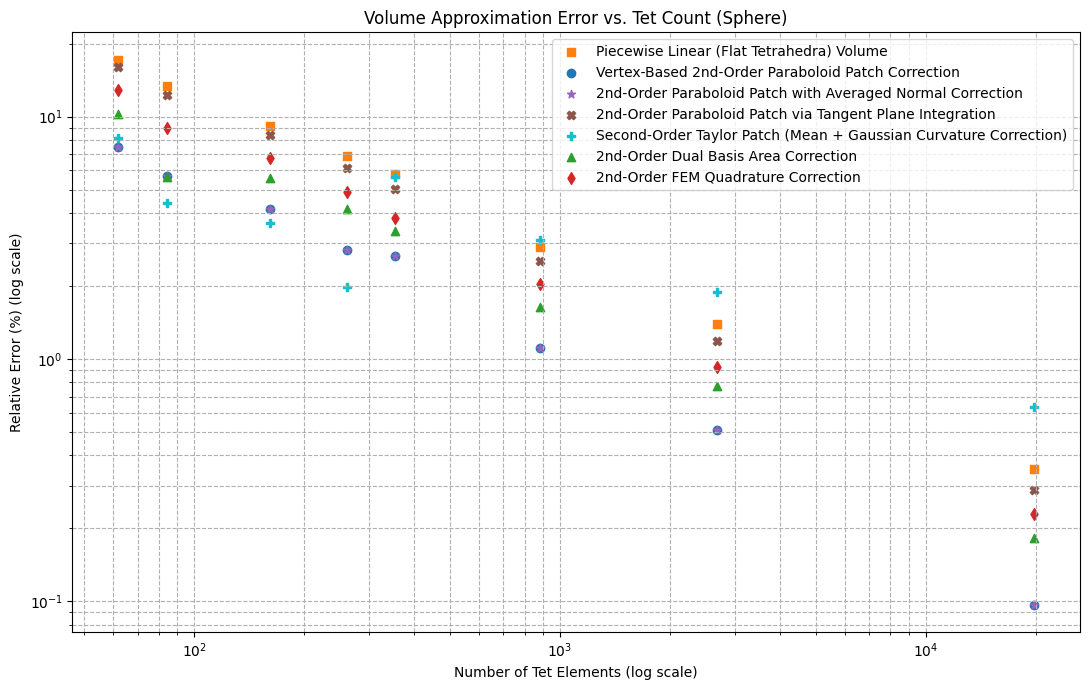

Saved to Sphere_Plot.csv


In [4]:
import functions
import importlib
import numpy as np
import pandas as pd

from functions import run_volume_error_study_sphere, plot_volume_error_vs_tets

# Reload functions.py to get latest edits (if you’ve just modified it)
importlib.reload(functions)

# For a unit sphere
ax_ = 1.0  # x-radius
ay_ = 1.0  # y-radius
az_ = 1.0  # z-radius

lc_values = np.linspace(0.1, 0.8, 8)

# Run error study
results = run_volume_error_study_sphere(ax_, ay_, az_, lc_values)
plot_volume_error_vs_tets(*results, geometry_name="Sphere")

# Save results to Sphere_Plot.csv
columns = [
    "Tet Count",
    "Piecewise Linear (Flat Tetrahedra) Volume",
    "Vertex-Based 2nd-Order Paraboloid Patch Correction",
    "2nd-Order Paraboloid Patch with Averaged Normal Correction",
    "2nd-Order Paraboloid Patch via Tangent Plane Integration",
    "Second-Order Taylor Patch (Mean + Gaussian Curvature Correction)",
    "2nd-Order Dual Basis Area Correction",
    "2nd-Order FEM Quadrature Correction"
]
data_dict = {col: res for col, res in zip(columns, results)}

df = pd.DataFrame(data_dict)
df.to_csv("Sphere_Plot.csv", index=False)
print("Saved to Sphere_Plot.csv")
